# WFP Food Prices - Data Exploration
#### UN World Food Programme

Investigation of food products and their development in countries with food insecurity, crises, and weaker markets, including geographic, categorical, and seasonal/time-based differentiation.

Goal: understand the structure of the dataset, identify relevant variables and explore potential directions for a visualization project.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

files = glob.glob("../data/*.csv")
print(files)

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df["date"] = pd.to_datetime(df["date"])
df = df[df["pricetype"] == "Retail"]

['../data\\wfp_food_prices_global_2015.csv', '../data\\wfp_food_prices_global_2016.csv', '../data\\wfp_food_prices_global_2017 (1).csv', '../data\\wfp_food_prices_global_2018.csv', '../data\\wfp_food_prices_global_2019.csv', '../data\\wfp_food_prices_global_2020.csv', '../data\\wfp_food_prices_global_2021.csv', '../data\\wfp_food_prices_global_2022.csv', '../data\\wfp_food_prices_global_2023.csv', '../data\\wfp_food_prices_global_2024.csv', '../data\\wfp_food_prices_global_2025.csv']


## Initial dataset overview

In [32]:
display("Shape:", df.shape)
# print the first few rows of the dataframe
display(df.head())
cat = df.select_dtypes(include="object").columns
df[cat] = df[cat].astype("category")

df.info()

'Shape:'

(2557252, 17)

,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,AFG,2015-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Bread,55,KG,actual,Retail,AFN,50.00,0.87
1,AFG,2015-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Rice (low quality),145,KG,actual,Retail,AFN,50.00,0.87
2,AFG,2015-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,cereals and tubers,Wheat,84,KG,actual,Retail,AFN,25.00,0.43
3,AFG,2015-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,non-food,Exchange rate,305,USD/LCU,actual,Retail,AFN,57.55,1.00
4,AFG,2015-01-15,Badakhshan,Faiz Abad,Fayzabad,266,37.12,70.58,non-food,Fuel (diesel),284,L,actual,Retail,AFN,53.25,0.93


C:\Users\User\AppData\Local\Temp\ipykernel_21364\856508802.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include="object").columns


<class 'pandas.DataFrame'>
Index: 2557252 entries, 0 to 2718011
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   countryiso3   category      
 1   date          datetime64[us]
 2   admin1        category      
 3   admin2        category      
 4   market        category      
 5   market_id     int64         
 6   latitude      float64       
 7   longitude     float64       
 8   category      category      
 9   commodity     category      
 10  commodity_id  int64         
 11  unit          category      
 12  priceflag     category      
 13  pricetype     category      
 14  currency      category      
 15  price         float64       
 16  usdprice      float64       
dtypes: category(10), datetime64[us](1), float64(4), int64(2)
memory usage: 190.3 MB


## Data Quality Check

In [33]:
display(df.isna().sum())

admin1_na = df[df["admin1"].isna()]

print(admin1_na["countryiso3"].value_counts())

print(df[df["countryiso3"] == "TUR"].shape[0])

display(admin1_na["date"].dt.year.value_counts().sort_index())

display(df.nunique())



countryiso3         0
date                0
admin1          12229
admin2          12229
market              0
market_id           0
latitude        12229
longitude       12229
category            0
commodity           0
commodity_id        0
unit                0
priceflag           0
pricetype           0
currency            0
price               0
usdprice         4231
dtype: int64

countryiso3
TUR    2633
NIC    2380
EGY    1256
KGZ     868
JPN     792
       ... 
TLS       0
TZA       0
UGA       0
YEM       0
ZMB       0
Name: count, Length: 88, dtype: int64
10864


date
2015    2043
2016    2131
2017    2226
2018    1779
2019    1399
2020     897
2021     890
2022     529
2023     193
2024     142
Name: count, dtype: int64

countryiso3         88
date               132
admin1             834
admin2            2346
market            4387
market_id         4411
latitude          2911
longitude         3118
category             8
commodity          778
commodity_id       778
unit               125
priceflag            3
pricetype            1
currency            76
price           230574
usdprice         21508
dtype: int64

## Key variable distributions

In [34]:
display(df["priceflag"].value_counts())
display(df["pricetype"].value_counts())
display(df["category"].value_counts())
display(df["commodity"].value_counts().head(20))
display(df["countryiso3"].value_counts())
display(len(df.query("countryiso3 == 'LBN'")))



priceflag
actual              1768121
aggregate            779245
actual,aggregate       9886
Name: count, dtype: int64

pricetype
Retail    2557252
Name: count, dtype: int64

category
cereals and tubers       751831
vegetables and fruits    461314
meat, fish and eggs      380264
pulses and nuts          252492
non-food                 251221
miscellaneous food       195754
oil and fats             191976
milk and dairy            72400
Name: count, dtype: int64

commodity
Sugar                     62650
Eggs                      47919
Onions                    46866
Tomatoes                  46447
Oil (vegetable)           46405
Salt                      44539
Rice (imported)           43299
Wheat flour               42697
Rice                      41719
Millet                    39704
Oil (palm)                39179
Maize (white)             38200
Meat (beef)               36710
Rice (local)              34703
Potatoes                  34360
Fuel (diesel)             32674
Maize                     29555
Sorghum                   27330
Groundnuts (shelled)      26402
Fuel (petrol-gasoline)    24835
Name: count, dtype: int64

countryiso3
IDN    225496
SYR    210187
PHL    129857
IND    123257
BDI    117212
        ...  
GTM       176
BTN       123
GAB       120
MEX        50
COL        49
Name: count, Length: 88, dtype: int64

26005

## 4. Retail vs wholesale

In [35]:
df_retail = df[df["pricetype"] == "Retail"].copy()

print("All countries:", df["countryiso3"].nunique())
print("Retail countries:", df_retail["countryiso3"].nunique())
print("Countries lost:", set(df["countryiso3"]) - set(df_retail["countryiso3"]))

All countries: 88
Retail countries: 88
Countries lost: set()


## 5. Candidate variables for the project

In [36]:
relevant_cols = [
    "countryiso3", "date", "market", "latitude", "longitude",
    "category", "commodity", "unit", "pricetype", "usdprice"
]

display(df[relevant_cols].head())

,countryiso3,date,market,latitude,longitude,category,commodity,unit,pricetype,usdprice
0,AFG,2015-01-15,Fayzabad,37.12,70.58,cereals and tubers,Bread,KG,Retail,0.87
1,AFG,2015-01-15,Fayzabad,37.12,70.58,cereals and tubers,Rice (low quality),KG,Retail,0.87
2,AFG,2015-01-15,Fayzabad,37.12,70.58,cereals and tubers,Wheat,KG,Retail,0.43
3,AFG,2015-01-15,Fayzabad,37.12,70.58,non-food,Exchange rate,USD/LCU,Retail,1.00
4,AFG,2015-01-15,Fayzabad,37.12,70.58,non-food,Fuel (diesel),L,Retail,0.93


## 6. First analytical checks

In [37]:
display(df.groupby("category")["usdprice"].mean().sort_values(ascending=False))
display(df.groupby("countryiso3")["usdprice"].mean().sort_values(ascending=False).head(20))
display(df.groupby("commodity")["usdprice"].mean().sort_values(ascending=False).head(20))

category
meat, fish and eggs      24.640336
non-food                  5.696199
milk and dairy            4.232315
pulses and nuts           3.831969
oil and fats              3.327834
cereals and tubers        2.481542
miscellaneous food        1.977053
vegetables and fruits     1.579476
Name: usdprice, dtype: float64

countryiso3
COL    245.937551
SOM    197.344108
ETH     71.756405
MRT     31.701100
LBN     27.239072
YEM     26.171572
SSD     14.523834
IRN     13.871228
BTN     13.697886
TCD     12.599209
LBR      8.416946
SYR      8.158832
PSE      6.873247
SDN      6.742495
MLI      6.397257
AGO      6.364781
JPN      5.140455
HTI      4.053113
TUR      3.493871
MWI      3.178355
Name: usdprice, dtype: float64

commodity
Livestock (Goat)                        904.112934
Meat (camel)                            727.595232
Livestock (camel)                       600.882507
Livestock (ox)                          496.356545
Livestock (sheep, one-year-old male)    419.227428
Livestock (bull)                        379.170000
 Livestock (bull, two-year-old)         355.097000
Livestock (cattle)                      315.982100
Livestock (sheep, two-year-old male)    287.822348
Lin seed                                163.583571
Oat                                     160.155313
Livestock (donkey)                      128.765000
Teff (white)                            117.424763
Teff (mixed)                            114.474072
Teff (red)                              114.320000
Teff (Sergegna)                         107.784545
Niger seed                               98.687692
Livestock (sheep, medium-sized male)     81.922210
Beans (fava)                             76.255876
Livestock (pig)      

In [38]:
print(df["countryiso3"].value_counts().to_string())

countryiso3
IDN    225496
SYR    210187
PHL    129857
IND    123257
BDI    117212
BEN    109600
UKR     87972
GMB     79232
COD     58170
GNB     55502
MLI     53986
CMR     52600
KGZ     52440
LBY     49127
ZMB     46783
BFA     44566
NGA     41886
YEM     41436
RWA     41432
IRQ     40955
MWI     40496
TZA     38479
ARM     35451
SSD     34586
TJK     34090
JOR     33056
LAO     31898
KHM     31492
MOZ     30935
MMR     30873
ETH     28617
AFG     28198
TCD     26669
CAF     26327
SOM     26290
LBN     26005
NPL     25723
BGD     24810
LKA     22219
UGA     21731
SEN     21554
MDG     19635
NER     19424
ZWE     17866
PSE     17777
SLE     16808
GIN     15829
VEN     15317
BOL     12699
MRT     11395
KEN     11214
TUR     10864
LBR     10849
GHA      9931
SDN      9439
PAK      7494
TLS      7094
HTI      6737
LSO      6277
CIV      5635
SWZ      5317
COG      5117
DZA      4962
DJI      4898
NAM      3464
NIC      3149
EGY      1774
MNG      1651
TGO      1578
IRN      1531
MDA     

## Fragestellungen

### Research Questions / Ideas

- Development of prices of essential goods such as eggs, milk, and bread within a single country

- Development of prices across all countries

- General price differences and differences in price development within a country across different regions  
  - Example: Syria — conflict areas vs. non-conflict areas

- World map heatmap showing countries with the highest food prices

- Geographical comparison by continents  
  - Compare food prices per category or per product  
  - Compare current price levels or changes over time

- Inclusion of fuel prices (e.g., diesel, non-food category)  
  - Compare alongside food prices

- Within food categories, analyze price changes over time  
  - Across countries  
  - For individual products  
  - Example: Top 10 most expensive products  
  - Example: Top 10 most common products (possibly manually selected)

## Erste Plots für Exploration

In [39]:
import numpy as np
import plotly.express as px
import pycountry
import numpy as np
import plotly.express as px
import pycountry

def iso_to_name(iso):
    country = pycountry.countries.get(alpha_3=iso)
    return country.name if country else iso

# Zuerst counts erstellen
counts = df.groupby("countryiso3").size().reset_index(name="count")

# Dann neue Spalten ergänzen
counts["log_count"] = np.log1p(counts["count"])
counts["country_name"] = counts["countryiso3"].apply(iso_to_name)

# Plot
fig = px.choropleth(
    counts,
    locations="countryiso3",
    locationmode="ISO-3",
    color="log_count",
    hover_name="country_name",
    hover_data={
        "count": True,
        "countryiso3": True,
        "log_count": False
    },
    color_continuous_scale="Reds",
    title="Dichte der Einträge pro Land (logarithmisch skaliert)"
)

fig.update_layout(
    title={
        "text": "Dichte der Einträge pro Land<br><sup>Log-Skalierung reduziert extreme Unterschiede zwischen Ländern</sup>",
        "x": 0.5
    }
)

fig.update_coloraxes(
    colorbar=dict(
        title="Anzahl Einträge (log-skaliert)",
    )
)



fig.show()

In [40]:
import nbformat
print(nbformat.__version__)

5.10.4


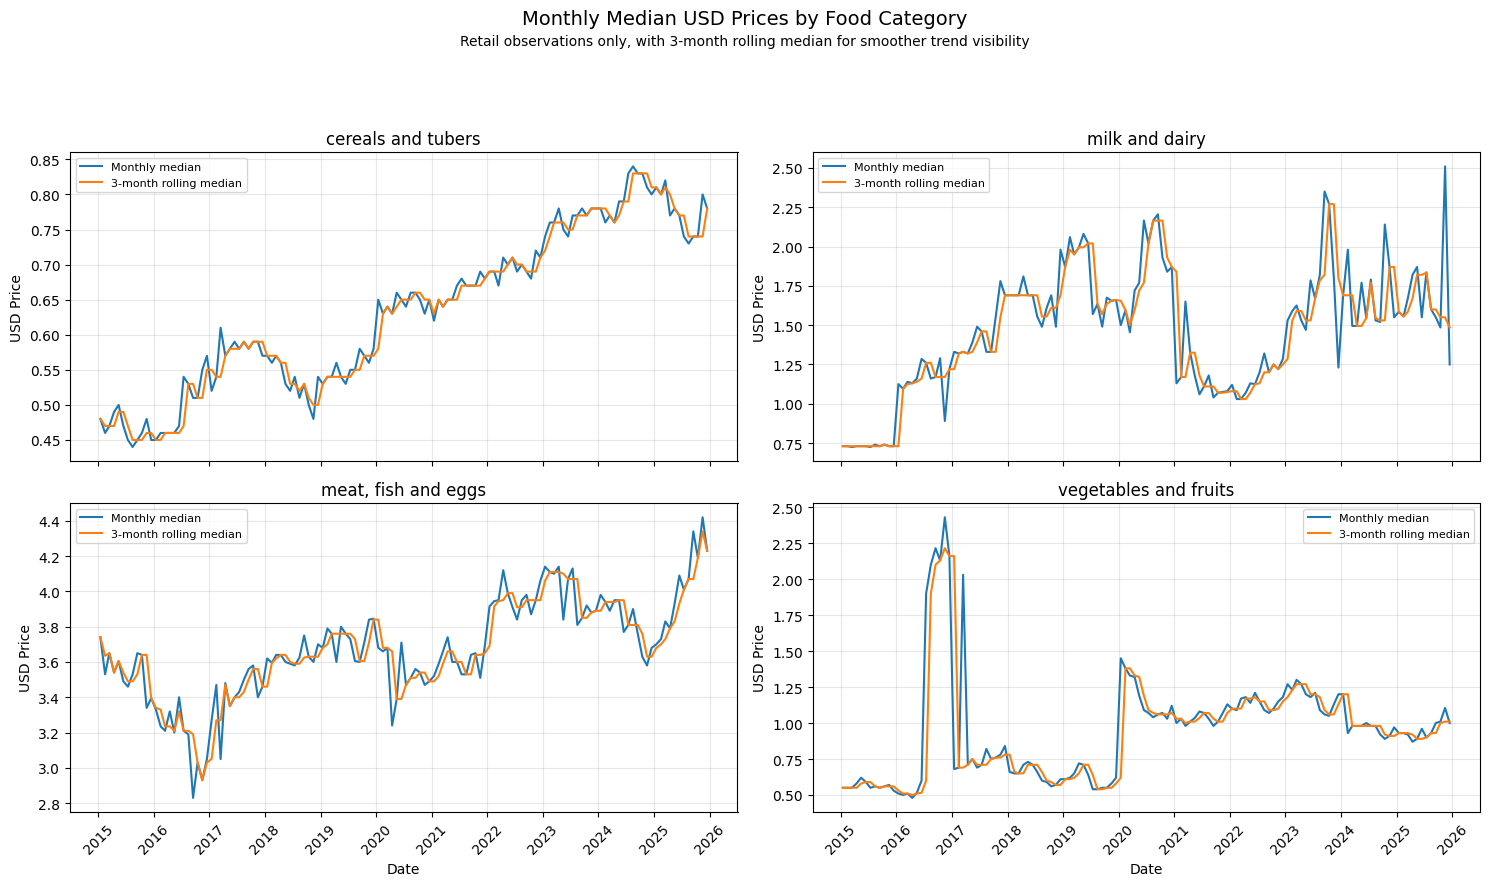

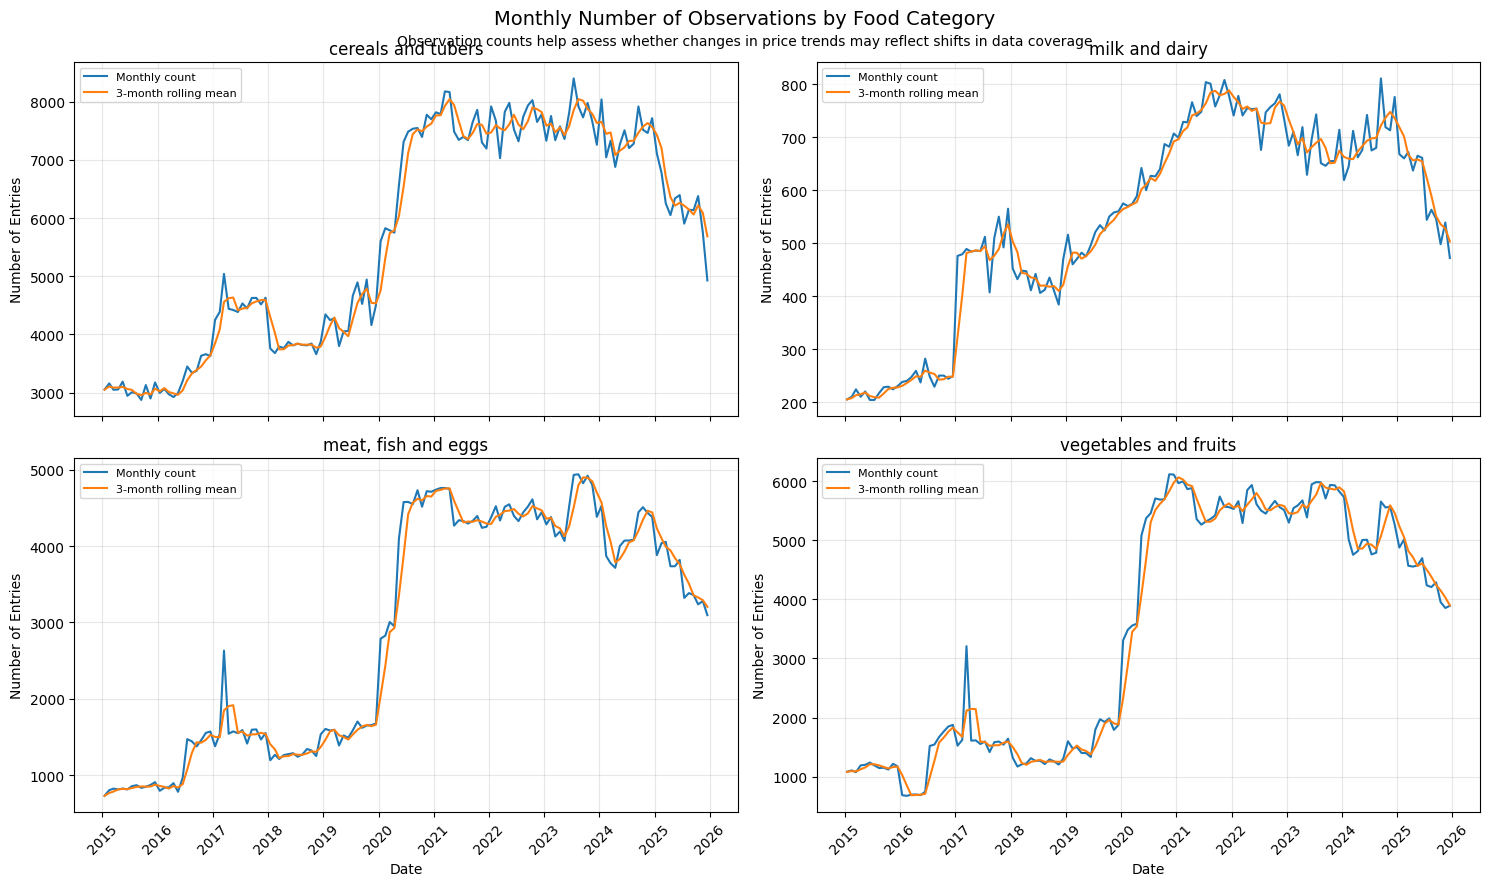

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1) Vorbereitung
# -----------------------------
cats = [
    "cereals and tubers",
    "milk and dairy",
    "meat, fish and eggs",
    "vegetables and fruits"
]

df["category_clean"] = df["category"].str.strip().str.lower()
df_subset = df[df["category_clean"].isin(cats)].copy()
df_subset["date"] = pd.to_datetime(df_subset["date"])

# Nur sinnvolle Zeilen behalten
df_subset = df_subset.dropna(subset=["date", "usdprice"])

# -----------------------------
# 2) Preis (Median pro Monat)
# -----------------------------
df_price = (
    df_subset
    .groupby(["date", "category_clean"])["usdprice"]
    .median()
    .reset_index()
    .sort_values(["category_clean", "date"])
)

# Rolling Median / geglätteter Trend
df_price["usdprice_roll3"] = (
    df_price
    .groupby("category_clean")["usdprice"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).median())
)

# -----------------------------
# 3) Counts pro Monat
# -----------------------------
df_counts = (
    df_subset
    .groupby(["date", "category_clean"])
    .size()
    .reset_index(name="count")
    .sort_values(["category_clean", "date"])
)

# Rolling Mean für Counts
df_counts["count_roll3"] = (
    df_counts
    .groupby("category_clean")["count"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# -----------------------------
# 4) Plot Preis
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for ax, cat in zip(axes, cats):
    temp = df_price[df_price["category_clean"] == cat]

    # Rohlinie
    sns.lineplot(
        data=temp,
        x="date",
        y="usdprice",
        ax=ax,
        label="Monthly median"
    )

    # Geglättete Linie
    sns.lineplot(
        data=temp,
        x="date",
        y="usdprice_roll3",
        ax=ax,
        label="3-month rolling median"
    )

    ax.set_title(cat)
    ax.set_xlabel("Date")
    ax.set_ylabel("USD Price")
    ax.grid(True, alpha=0.3)

    # Jahresanzeige sauber
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Labels leicht drehen
    ax.tick_params(axis="x", rotation=45)

    # Legende klein halten
    ax.legend(fontsize=8)

fig.suptitle(
    "Monthly Median USD Prices by Food Category",
    fontsize=14
)

fig.text(
    0.5, 0.94,
    "Retail observations only, with 3-month rolling median for smoother trend visibility",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# -----------------------------
# 5) Plot Counts
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for ax, cat in zip(axes, cats):
    temp = df_counts[df_counts["category_clean"] == cat]

    # Rohlinie
    sns.lineplot(
        data=temp,
        x="date",
        y="count",
        ax=ax,
        label="Monthly count"
    )

    # Geglättete Linie
    sns.lineplot(
        data=temp,
        x="date",
        y="count_roll3",
        ax=ax,
        label="3-month rolling mean"
    )

    ax.set_title(cat)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of Entries")
    ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

fig.suptitle(
    "Monthly Number of Observations by Food Category",
    fontsize=14
)

fig.text(
    0.5, 0.94,
    "Observation counts help assess whether changes in price trends may reflect shifts in data coverage",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

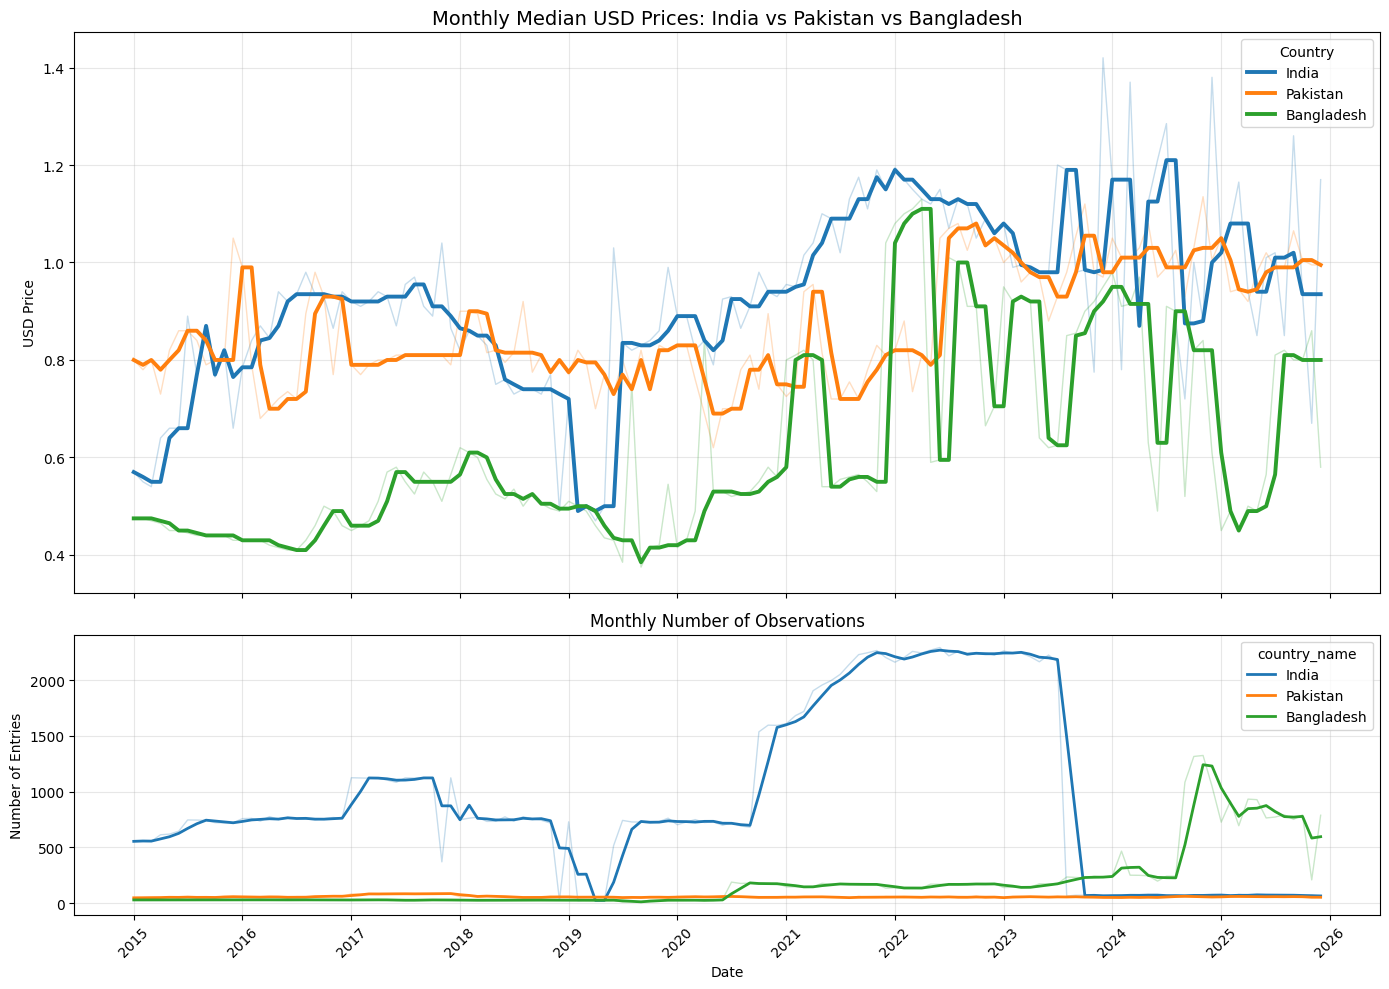

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1) Vorbereitung
# -----------------------------
countries = ["IND", "PAK", "BGD"]

df_c = df[df["countryiso3"].isin(countries)].copy()
df_c["date"] = pd.to_datetime(df_c["date"])
df_c = df_c.dropna(subset=["date", "usdprice"])

# Falls du wirklich monatliche Daten hast, ist Monatsstart sinnvoll
df_c["date"] = df_c["date"].dt.to_period("M").dt.to_timestamp()

# -----------------------------
# 2) Medianpreis pro Monat und Land
# -----------------------------
df_price = (
    df_c
    .groupby(["date", "countryiso3"])["usdprice"]
    .median()
    .reset_index()
    .sort_values(["countryiso3", "date"])
)

# -----------------------------
# 3) Counts pro Monat und Land
# -----------------------------
df_counts = (
    df_c
    .groupby(["date", "countryiso3"])
    .size()
    .reset_index(name="count")
    .sort_values(["countryiso3", "date"])
)

# -----------------------------
# 4) Vollständige Monatsachse erzwingen
# -----------------------------
full_dates = pd.date_range(
    start=df_price["date"].min(),
    end=df_price["date"].max(),
    freq="MS"
)

price_fixed = []
count_fixed = []

for country in countries:
    # Preis
    temp_price = (
        df_price[df_price["countryiso3"] == country]
        .set_index("date")
        .reindex(full_dates)
    )
    temp_price["countryiso3"] = country
    temp_price["usdprice"] = temp_price["usdprice"].interpolate(method="linear")
    temp_price = temp_price.reset_index().rename(columns={"index": "date"})
    price_fixed.append(temp_price)

    # Counts
    temp_count = (
        df_counts[df_counts["countryiso3"] == country]
        .set_index("date")
        .reindex(full_dates)
    )
    temp_count["countryiso3"] = country
    temp_count["count"] = temp_count["count"].fillna(0)
    temp_count = temp_count.reset_index().rename(columns={"index": "date"})
    count_fixed.append(temp_count)

df_price_fixed = pd.concat(price_fixed, ignore_index=True)
df_counts_fixed = pd.concat(count_fixed, ignore_index=True)

# -----------------------------
# 5) Rolling-Median / Rolling-Mean
# -----------------------------
df_price_fixed["usdprice_roll3"] = (
    df_price_fixed
    .groupby("countryiso3")["usdprice"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).median())
)

df_counts_fixed["count_roll3"] = (
    df_counts_fixed
    .groupby("countryiso3")["count"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# -----------------------------
# 6) Ländernamen schöner machen
# -----------------------------
name_map = {
    "IND": "India",
    "PAK": "Pakistan",
    "BGD": "Bangladesh"
}

df_price_fixed["country_name"] = df_price_fixed["countryiso3"].map(name_map)
df_counts_fixed["country_name"] = df_counts_fixed["countryiso3"].map(name_map)

# Reihenfolge für Legende
order = ["India", "Pakistan", "Bangladesh"]

# -----------------------------
# 7) Plot: oben Preise, unten Counts
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# --- oberer Plot: Preise ---
sns.lineplot(
    data=df_price_fixed,
    x="date",
    y="usdprice",
    hue="country_name",
    hue_order=order,
    ax=axes[0],
    linewidth=1,
    alpha=0.25,
    legend=False
)

sns.lineplot(
    data=df_price_fixed,
    x="date",
    y="usdprice_roll3",
    hue="country_name",
    hue_order=order,
    ax=axes[0],
    linewidth=2.8
)

axes[0].set_title("Monthly Median USD Prices: India vs Pakistan vs Bangladesh", fontsize=14)
axes[0].set_ylabel("USD Price")
axes[0].set_xlabel("")
axes[0].grid(True, alpha=0.3)

# --- unterer Plot: Counts ---
sns.lineplot(
    data=df_counts_fixed,
    x="date",
    y="count",
    hue="country_name",
    hue_order=order,
    ax=axes[1],
    linewidth=1,
    alpha=0.25,
    legend=False
)

sns.lineplot(
    data=df_counts_fixed,
    x="date",
    y="count_roll3",
    hue="country_name",
    hue_order=order,
    ax=axes[1],
    linewidth=2
)

axes[1].set_title("Monthly Number of Observations", fontsize=12)
axes[1].set_ylabel("Number of Entries")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

# -----------------------------
# 8) Jahresachse sauber formatieren
# -----------------------------
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)

# Nur eine Legende oben behalten
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Country")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21364\438960295.py:51: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


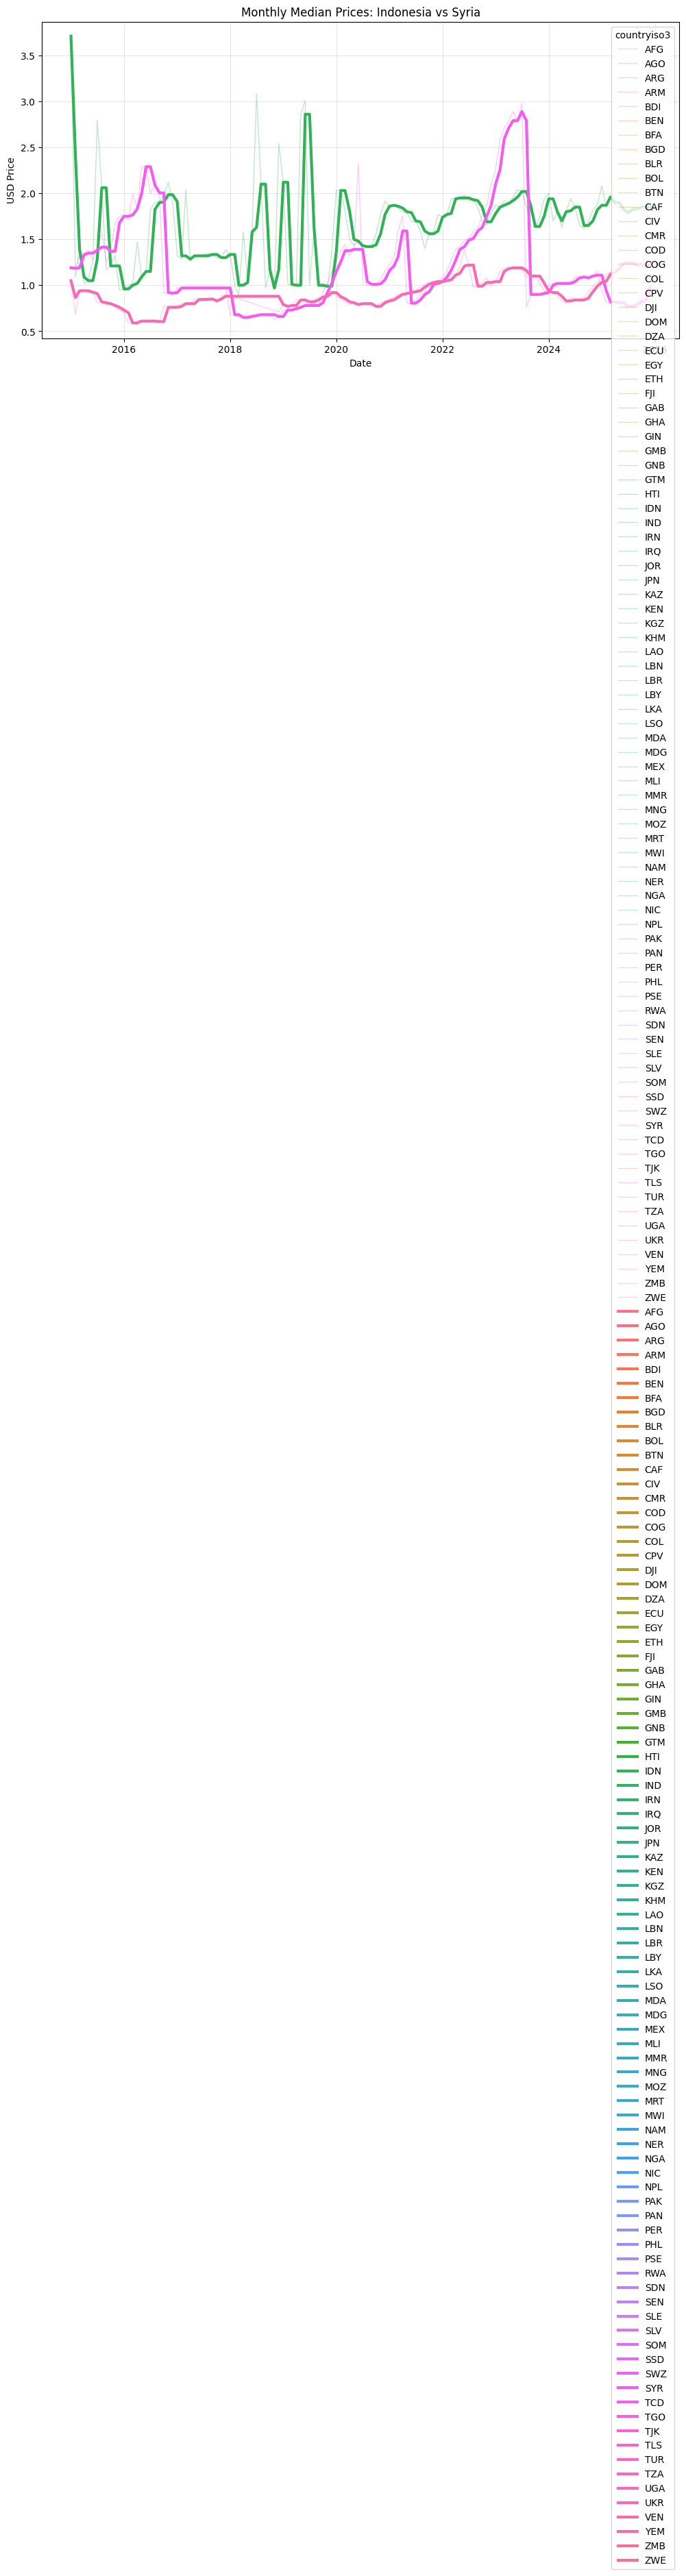

In [43]:
countries = ["IDN", "SYR", "UKR"]

df_c = df[df["countryiso3"].isin(countries)].copy()
df_c["date"] = pd.to_datetime(df_c["date"])
df_c = df_c.dropna(subset=["date", "usdprice"])

df_c["date"] = df_c["date"].dt.to_period("M").dt.to_timestamp()

# Median pro Monat
df_price = (
    df_c
    .groupby(["date", "countryiso3"])["usdprice"]
    .median()
    .reset_index()
    .sort_values(["countryiso3", "date"])
)

# Rolling Median
df_price["usdprice_roll3"] = (
    df_price
    .groupby("countryiso3")["usdprice"]
    .transform(lambda x: x.rolling(3, min_periods=1).median())
)

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_price,
    x="date",
    y="usdprice",
    hue="countryiso3",
    linewidth=1,
    alpha=0.3
)

sns.lineplot(
    data=df_price,
    x="date",
    y="usdprice_roll3",
    hue="countryiso3",
    linewidth=3,
    legend=True
)

plt.title("Monthly Median Prices: Indonesia vs Syria")
plt.xlabel("Date")
plt.ylabel("USD Price")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [44]:
crisis = ["SYR", "LBN", "UKR"]

df_crisis = (
    df[df["countryiso3"].isin(crisis)]
    .assign(year=df["date"].dt.year)
)

### Fehlende Werte (admin1-Spalte)

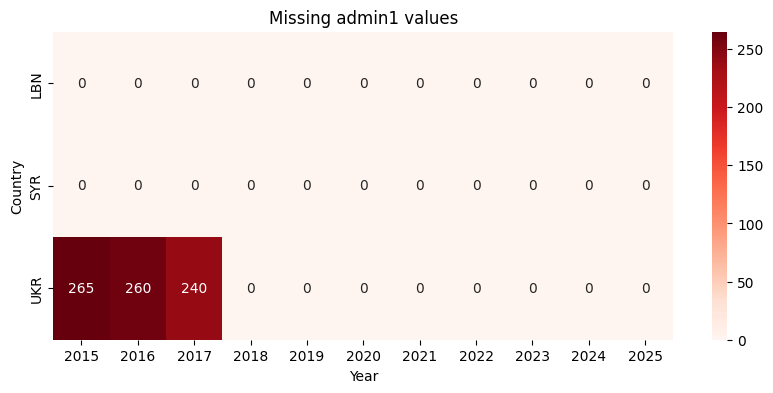

In [45]:
admin1_missing = (
    df_crisis
    .groupby(["countryiso3", "year"])["admin1"]
    .apply(lambda x: x.isna().sum())
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    admin1_missing,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("Missing admin1 values")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

### Alle fehlenden Werte 

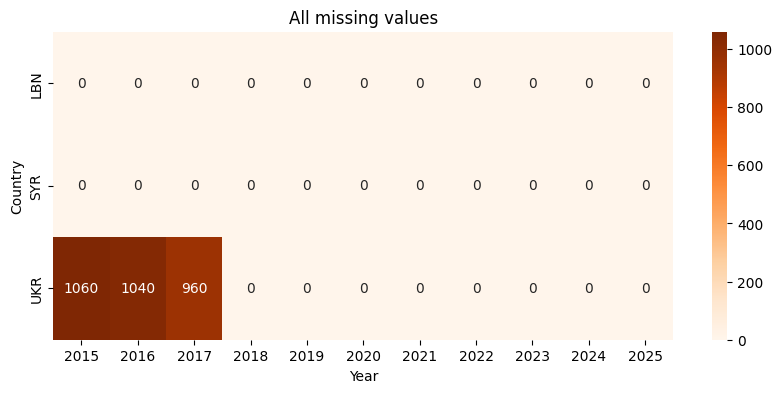

In [46]:
all_missing = (
    df_crisis
    .groupby(["countryiso3", "year"])
    .apply(lambda x: x.isna().sum().sum())
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    all_missing,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("All missing values")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

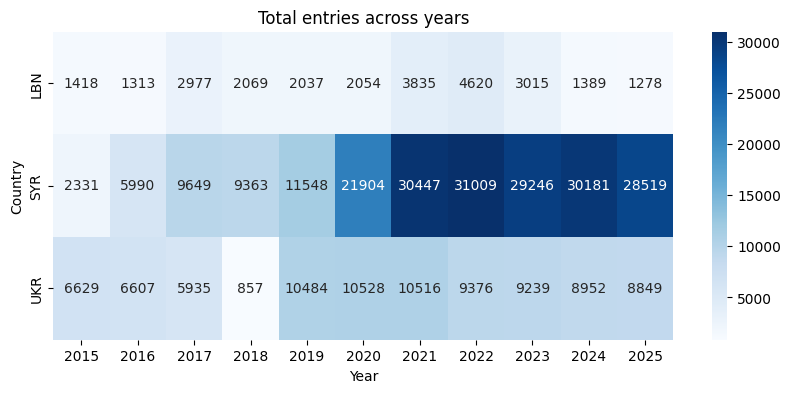

admin2            765
admin1            765
longitude         765
latitude          765
date                0
countryiso3         0
market_id           0
market              0
category            0
commodity           0
commodity_id        0
unit                0
priceflag           0
pricetype           0
currency            0
price               0
usdprice            0
category_clean      0
dtype: int64

In [47]:
total_entries = (
    df_crisis
    .groupby(["countryiso3", "year"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 4))

sns.heatmap(
    total_entries,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Total entries across years")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()


ukr = df[df["countryiso3"] == "UKR"]
ukr.isna().sum().sort_values(ascending=False)

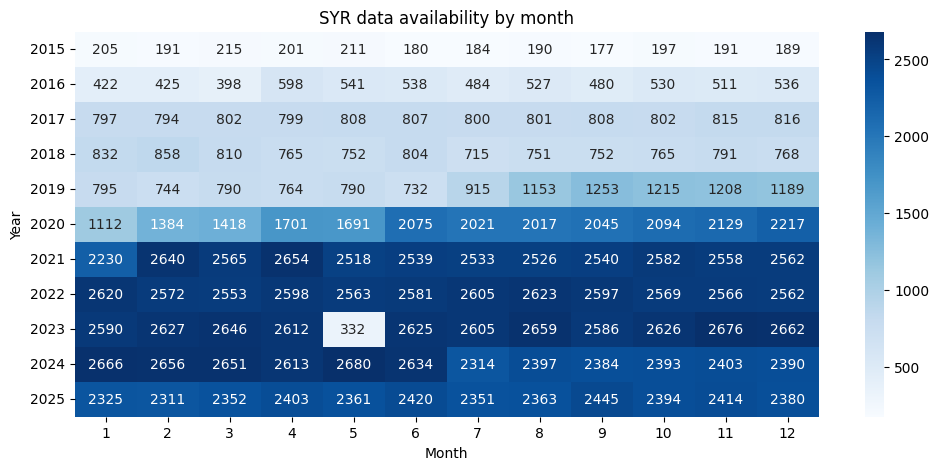

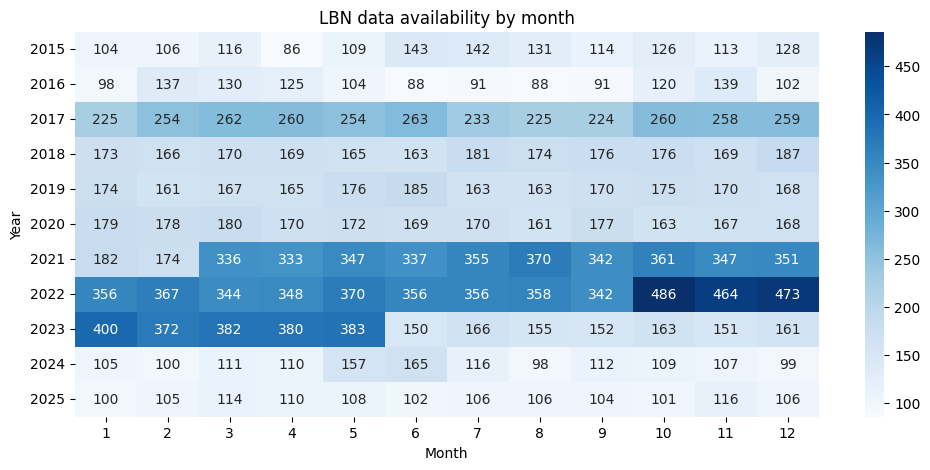

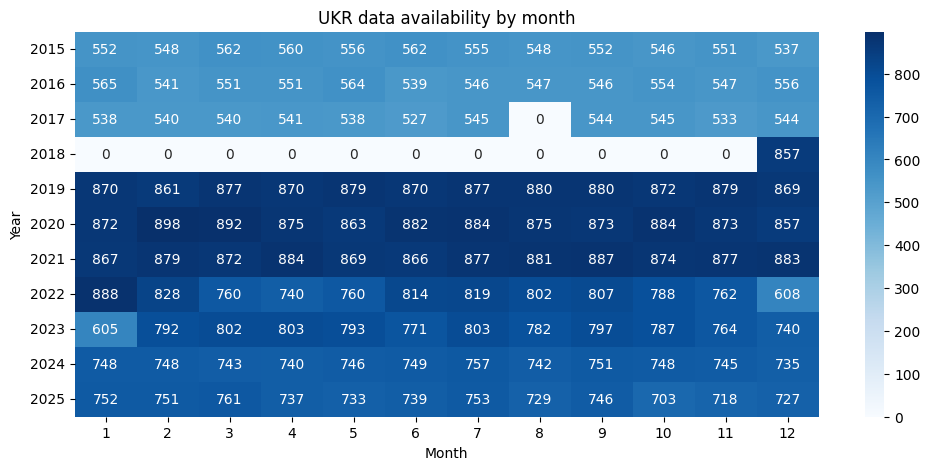

In [48]:
crisis = ["SYR", "LBN", "UKR"]

time_coverage = (
    df[df["countryiso3"].isin(crisis)]
    .assign(
        year=lambda x: x["date"].dt.year,
        month=lambda x: x["date"].dt.month
    )
    .groupby(["countryiso3", "year", "month"])
    .size()
    .reset_index(name="count")
)

for country in crisis:
    
    heatmap_data = (
        time_coverage[time_coverage["countryiso3"] == country]
        .pivot(
            index="year",
            columns="month",
            values="count"
        )
        .fillna(0)
    )

    plt.figure(figsize=(12, 5))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="Blues"
    )

    plt.title(f"{country} data availability by month")
    plt.xlabel("Month")
    plt.ylabel("Year")
    plt.show()

In [49]:
for country in crisis:
    
    country_df = df[df["countryiso3"] == country]

    full_range = pd.period_range(
        country_df["date"].min(),
        country_df["date"].max(),
        freq="M"
    )

    existing = country_df["date"].dt.to_period("M").unique()

    missing = full_range.difference(existing)

    print(f"\n{country} missing months:")
    print(missing)


SYR missing months:
PeriodIndex([], dtype='period[M]')

LBN missing months:
PeriodIndex([], dtype='period[M]')

UKR missing months:
PeriodIndex(['2017-08', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05',
             '2018-06', '2018-07', '2018-08', '2018-09', '2018-10', '2018-11'],
            dtype='period[M]')


## Fragestellungen & Vorbereitung

### Fragestellung 1 — Krisen & Preisschocks
*Wie spiegeln sich Krisen (Krieg, Hyperinflation) in Lebensmittelpreisen wider?*

Länder: Syrien, Ukraine, Libanon, Venezuela — alle mit klaren Krisen-Zeitpunkten.  
Vorbereitung: Zeitreihe (monatlicher Medianpreis in USD) pro Land, annotiert mit Ereignissen (z. B. Kriegsbeginn, Sanktionen). Fokus auf 3–4 Standardprodukte (Weizen, Reis, Öl).

**Benötigt:** `countryiso3`, `date`, `commodity`, `usdprice` — plus externe Ereignistabelle (manuell, ca. 5–10 Einträge).

---

### Fragestellung 2 — Globale Preisniveaus im Vergleich
*Welche Länder zahlen strukturell am meisten für Grundnahrungsmittel?*

Aggregation: Medianpreis in USD pro Land, gefiltert auf häufige Commodities (Zucker, Reis, Mehl, Eier).  
Vorbereitung: Choropleth-Karte mit Medianpreisen, ggf. normiert auf ein Basisprodukt.

**Benötigt:** `countryiso3`, `commodity`, `usdprice` — gefiltert auf Top-Commodities mit breiter Länderabdeckung (Verfügbarkeit prüfen).

---

### Fragestellung 3 — Globaler Preistrend 2015–2025
*Wie haben sich Lebensmittelpreise global entwickelt — insbesondere rund um COVID-19 und den Ukraine-Krieg?*

Aggregation: Globaler Medianpreis pro Monat und Kategorie (z. B. `cereals and tubers`, `oil and fats`).  
Vorbereitung: Zeitreihe über alle Länder hinweg, gewichtet oder ungewichtet — Länderabdeckung pro Monat im Blick behalten (lückenhafte Länder können Trend verzerren).

**Benötigt:** `date`, `category`, `usdprice` — plus Abklärung welche Länder durchgehend Daten liefern (Lückencheck).
